In [4]:
import myQMLlib as myQML
import numpy as np
import matplotlib.pyplot as plt
import time

#Code to automatically reload the myQMLfunctions module when it is edited
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


-------- (Shots = 0, Realizations = 100) --------
Evaluating N_train = 10...
  -> QELM MSE: 0.0000
  -> K-LE MSE: 0.0000
  -> K-SW MSE: 0.0000
  -> Time:     34.1s
Evaluating N_train = 30...
  -> QELM MSE: 0.0000
  -> K-LE MSE: 0.0000
  -> K-SW MSE: 0.0000
  -> Time:     33.7s
Evaluating N_train = 50...
  -> QELM MSE: 0.0000
  -> K-LE MSE: 0.0000
  -> K-SW MSE: 0.0000
  -> Time:     52.3s
Evaluating N_train = 100...
  -> QELM MSE: 0.0000
  -> K-LE MSE: 0.0000
  -> K-SW MSE: 0.0000
  -> Time:     46.4s
Evaluating N_train = 500...
  -> QELM MSE: 0.0000
  -> K-LE MSE: 0.0000
  -> K-SW MSE: 0.0000
  -> Time:     130.2s
Evaluating N_train = 1000...
  -> QELM MSE: 0.0000
  -> K-LE MSE: 0.0000
  -> K-SW MSE: 0.0000
  -> Time:     373.2s
Evaluating N_train = 2000...
  -> QELM MSE: 0.0000
  -> K-LE MSE: 0.0000
  -> K-SW MSE: 0.0000
  -> Time:     2100.4s
Experiment finished in 46.2 minutes.


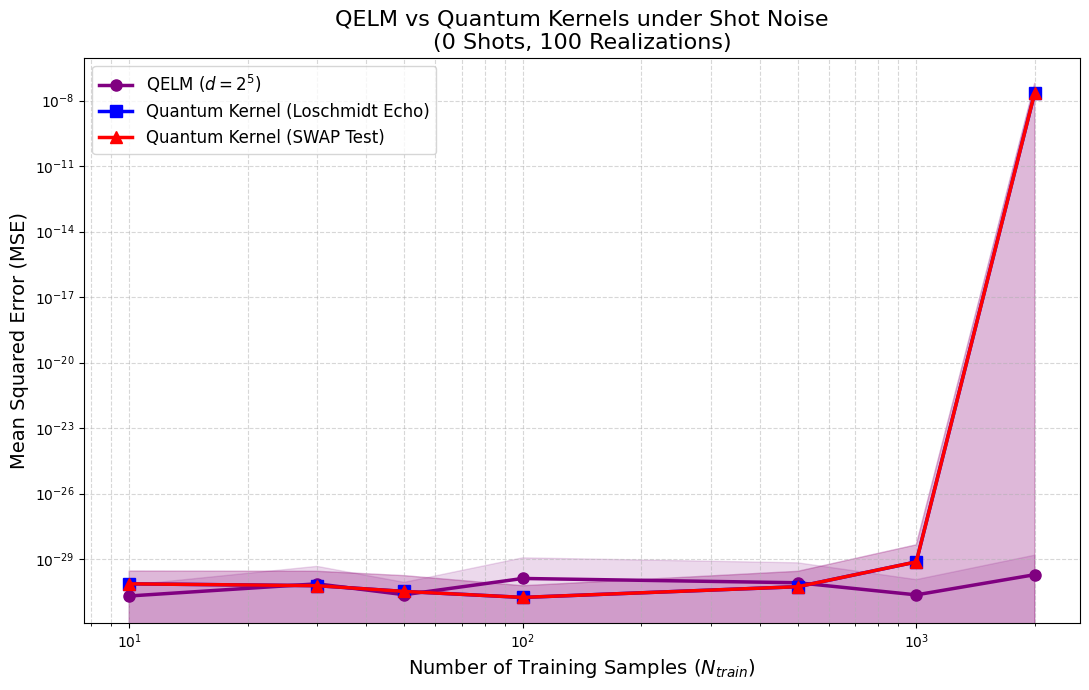

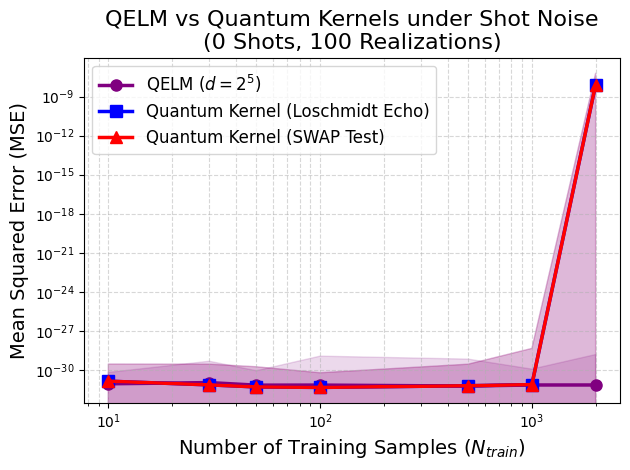

In [5]:
####### Settings #########
N_train_list = [10, 30, 50, 100,500, 1000, 2000]
N_test = 200
num_realizations = 100
num_shots = 0

reg_lambda = 0

#QELM reservoir physical setup
d_in = 2
d_res = 64
d_out = d_in * d_res
povm = myQML.generate_computational_povm(d_res)  # Using computational basis POVM for a more deterministic feature map
num_povm_elements = len(povm)


# Storage dictionaries
results = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
results_median = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
stds = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

print(f"-------- (Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

for N_train in N_train_list:
    print(f"Evaluating N_train = {N_train}...")
    mse_runs = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
    step_time = time.time()

    for r in range(num_realizations):
        ds = myQML.QuantumDatasetGenerator(N_train, N_test, myQML.X)
        ds.generate_density_matrices_vec()
        ds.compute_expectation_values_vec()

        rho_train, y_train = ds.get_training_dataset()
        rho_test, y_test = ds.get_test_dataset()

        # QELM
        V = myQML.random_isometry(d_in, d_in * d_res)
        qelm = myQML.QuantumExtremeLearningMachine(
            isometry=V, 
            povm=povm, 
            bipartite_dims=(d_in, d_res), 
            keep_subsystem=1, 
            num_shots=num_shots
        )
        qelm.fit_vec(rho_train, y_train)
        mse_runs['QELM'].append(np.mean((qelm.predict_vec(rho_test) - y_test)**2))
        
        # Kernel LE
        kernel_le = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_le.fit_vec(rho_train, y_train, "le")
        mse_runs['Kernel_LE'].append(np.mean((kernel_le.predict_vec(rho_test) - y_test)**2))

        # Kernel SWAP
        kernel_swap = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_swap.fit_vec(rho_train, y_train, "swap")
        mse_runs['Kernel_SWAP'].append(np.mean((kernel_swap.predict_vec(rho_test) - y_test)**2))

    # Store results
    for key in results.keys():
        results[key].append(np.mean(mse_runs[key]))
        results_median[key].append(np.median(mse_runs[key]))
        stds[key].append(np.std(mse_runs[key]))

    print(f"  -> QELM MSE: {results['QELM'][-1]:.4f}")
    print(f"  -> K-LE MSE: {results['Kernel_LE'][-1]:.4f}")
    print(f"  -> K-SW MSE: {results['Kernel_SWAP'][-1]:.4f}")
    print(f"  -> Time:     {time.time() - step_time:.1f}s")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")

# Plot
plt.figure(figsize=(11, 7))
N_arr = np.array(N_train_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=2^5$)', 
          'Kernel_LE': 'Quantum Kernel (Loschmidt Echo)', 
          'Kernel_SWAP': 'Quantum Kernel (SWAP Test)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results.keys():
    mean_arr = np.array(results[model])
    median_arr = np.array(results_median[model])
    std_arr = np.array(stds[model])
    
    plt.plot(N_arr, mean_arr, label=labels[model], color=colors[model], 
             marker=markers[model], linewidth=2.5, markersize=8)
    plt.fill_between(N_arr, mean_arr - std_arr, mean_arr + std_arr, 
                     color=colors[model], alpha=0.15)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'QELM vs Quantum Kernels under Shot Noise\n({num_shots} Shots, {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

for model in results.keys():
    mean_arr = np.array(results[model])
    median_arr = np.array(results_median[model])
    std_arr = np.array(stds[model])
    
    plt.plot(N_arr, median_arr, label=labels[model], color=colors[model], 
             marker=markers[model], linewidth=2.5, markersize=8)
    plt.fill_between(N_arr, mean_arr - std_arr, mean_arr + std_arr, 
                     color=colors[model], alpha=0.15)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'QELM vs Quantum Kernels under Shot Noise\n({num_shots} Shots, {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

--- Setting up mock quantum data ---
Generated 800 training samples and 200 testing samples.

=== BENCHMARK 1: NOISLESS (num_shots=None) ===
Standard time:   0.7808 sec | MSE: 0.00000000
Vectorized time: 0.1256 sec | MSE: 0.00000000
Speedup:         6.22x faster
Are predictions identical? True

=== BENCHMARK 2: FINITE SHOT NOISE (num_shots=100) ===
Standard time:   0.8612 sec | MSE: 0.00000164
Vectorized time: 0.0750 sec | MSE: 0.00000174
Speedup:         11.48x faster
Are predictions identical? False (Expected: False)



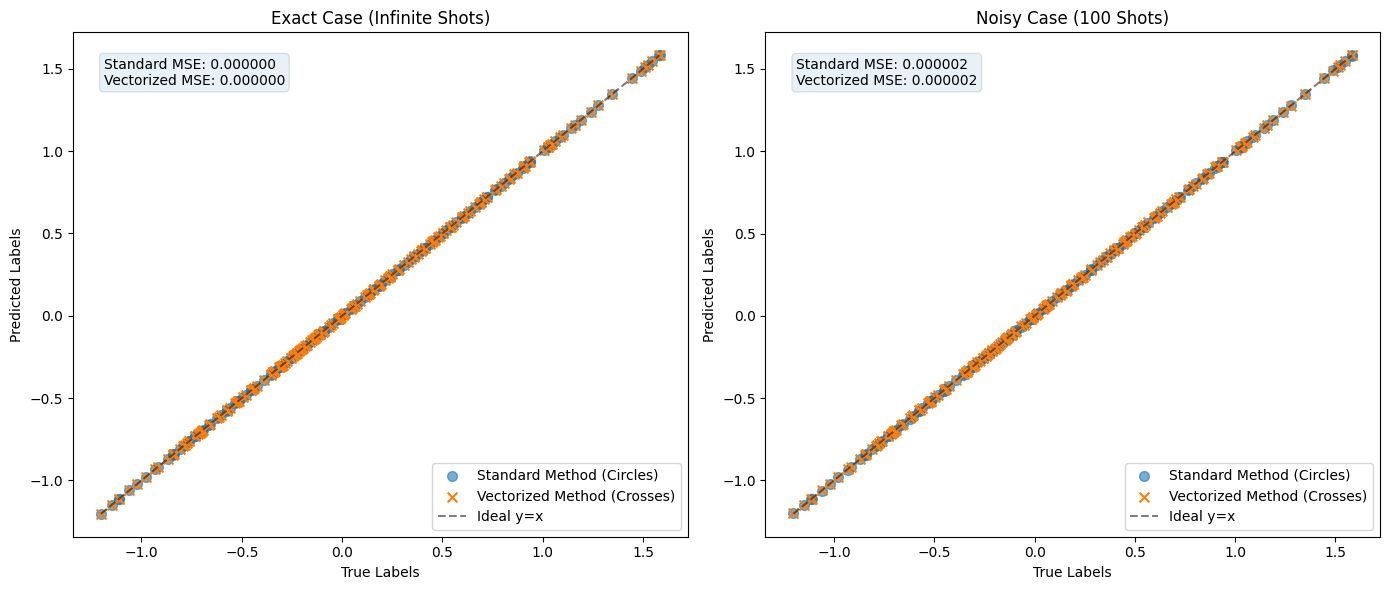

In [6]:
import numpy as np
import time
import matplotlib.pyplot as plt


def generate_random_density_matrix(dim):
    """Generates a random valid density matrix (Hermitian, positive semi-definite, trace 1)."""
    A = np.random.randn(dim, dim) + 1j * np.random.randn(dim, dim)
    rho = A @ A.conj().T
    return rho / np.trace(rho)

def generate_random_isometry(dim_out, dim_in):
    """Generates a random isometry matrix V where V^dagger @ V = Identity."""
    A = np.random.randn(dim_out, dim_in) + 1j * np.random.randn(dim_out, dim_in)
    Q, R = np.linalg.qr(A)
    return Q

def run_benchmark_and_plot():
    # --- 1. SETUP MOCK QUANTUM DATA ---
    print("--- Setting up mock quantum data ---")
    N_train = 800
    N_test = 200
    dim_in = 2
    
    bipartite_dims = (2, 16)
    dim_total = bipartite_dims[0] * bipartite_dims[1]
    keep_subsystem = 1

    isometry = generate_random_isometry(dim_total, dim_in)
    povm = [np.diag([1 if i == j else 0 for j in range(16)]) for i in range(16)]

    # Create a random observable to act as the "True" underlying function we want to learn
    # Target function: y_i = Tr(O * rho_i)
    O_target = np.random.randn(dim_in, dim_in)
    O_target = O_target + O_target.T  # Make it symmetric/Hermitian so labels are real

    # Generate Train and Test sets
    rho_train = [generate_random_density_matrix(dim_in) for _ in range(N_train)]
    y_train = np.array([np.real(np.trace(O_target @ rho)) for rho in rho_train])

    rho_test = [generate_random_density_matrix(dim_in) for _ in range(N_test)]
    y_test = np.array([np.real(np.trace(O_target @ rho)) for rho in rho_test])

    print(f"Generated {N_train} training samples and {N_test} testing samples.\n")

    # ==========================================================
    # === BENCHMARK 1: EXACT QELM (num_shots = None)         ===
    # ==========================================================
    print("=== BENCHMARK 1: NOISLESS (num_shots=None) ===")
    qelm_exact = myQML.QuantumExtremeLearningMachine(
        isometry=isometry, povm=povm, bipartite_dims=bipartite_dims, 
        keep_subsystem=keep_subsystem, num_shots=None
    )

    # Standard Fit & Predict
    t0 = time.perf_counter()
    qelm_exact.fit(rho_train, y_train)
    y_pred_std_exact = np.real(qelm_exact.predict(rho_test))
    time_std_exact = time.perf_counter() - t0

    # Vectorized Fit & Predict
    t0 = time.perf_counter()
    qelm_exact.fit_vec(rho_train, y_train)
    y_pred_vec_exact = np.real(qelm_exact.predict_vec(rho_test))
    time_vec_exact = time.perf_counter() - t0

    mse_std_exact = np.mean((y_test - y_pred_std_exact)**2)
    mse_vec_exact = np.mean((y_test - y_pred_vec_exact)**2)

    print(f"Standard time:   {time_std_exact:.4f} sec | MSE: {mse_std_exact:.8f}")
    print(f"Vectorized time: {time_vec_exact:.4f} sec | MSE: {mse_vec_exact:.8f}")
    print(f"Speedup:         {time_std_exact / time_vec_exact:.2f}x faster")
    print(f"Are predictions identical? {np.allclose(y_pred_std_exact, y_pred_vec_exact, atol=1e-10)}\n")


    # ==========================================================
    # === BENCHMARK 2: NOISY QELM (num_shots = 100)          ===
    # ==========================================================
    print("=== BENCHMARK 2: FINITE SHOT NOISE (num_shots=100) ===")
    qelm_noisy = myQML.QuantumExtremeLearningMachine(
        isometry=isometry, povm=povm, bipartite_dims=bipartite_dims, 
        keep_subsystem=keep_subsystem, num_shots=10000000
    )

    # Standard Fit & Predict
    t0 = time.perf_counter()
    qelm_noisy.fit(rho_train, y_train)  # Internally samples from multinomial
    y_pred_std_noisy = np.real(qelm_noisy.predict(rho_test))
    time_std_noisy = time.perf_counter() - t0

    # Vectorized Fit & Predict
    t0 = time.perf_counter()
    qelm_noisy.fit_vec(rho_train, y_train) # Internally samples from multinomial AGAIN
    y_pred_vec_noisy = np.real(qelm_noisy.predict_vec(rho_test))
    time_vec_noisy = time.perf_counter() - t0

    mse_std_noisy = np.mean((y_test - y_pred_std_noisy)**2)
    mse_vec_noisy = np.mean((y_test - y_pred_vec_noisy)**2)

    print(f"Standard time:   {time_std_noisy:.4f} sec | MSE: {mse_std_noisy:.8f}")
    print(f"Vectorized time: {time_vec_noisy:.4f} sec | MSE: {mse_vec_noisy:.8f}")
    print(f"Speedup:         {time_std_noisy / time_vec_noisy:.2f}x faster")
    print(f"Are predictions identical? {np.array_equal(y_pred_std_noisy, y_pred_vec_noisy)} (Expected: False)\n")

    # ==========================================================
    # === PLOTTING RESULTS                                   ===
    # ==========================================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Plot 1: Exact Case
    ax1.set_title("Exact Case (Infinite Shots)")
    ax1.scatter(y_test, y_pred_std_exact, alpha=0.6, s=50, label='Standard Method (Circles)')
    ax1.scatter(y_test, y_pred_vec_exact, marker='x', s=50, label='Vectorized Method (Crosses)')
    
    # Ideal y=x line
    min_val, max_val = min(y_test), max(y_test)
    ax1.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Ideal y=x')
    
    ax1.set_xlabel("True Labels")
    ax1.set_ylabel("Predicted Labels")
    ax1.legend()
    ax1.text(0.05, 0.95, f"Standard MSE: {mse_std_exact:.6f}\nVectorized MSE: {mse_vec_exact:.6f}", 
             transform=ax1.transAxes, verticalalignment='top', bbox=dict(boxstyle="round", alpha=0.1))

    # Plot 2: Noisy Case
    ax2.set_title("Noisy Case (100 Shots)")
    ax2.scatter(y_test, y_pred_std_noisy, alpha=0.6, s=50, label='Standard Method (Circles)')
    ax2.scatter(y_test, y_pred_vec_noisy, marker='x', s=50, label='Vectorized Method (Crosses)')
    
    # Ideal y=x line
    ax2.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Ideal y=x')

    ax2.set_xlabel("True Labels")
    ax2.set_ylabel("Predicted Labels")
    ax2.legend()
    ax2.text(0.05, 0.95, f"Standard MSE: {mse_std_noisy:.6f}\nVectorized MSE: {mse_vec_noisy:.6f}", 
             transform=ax2.transAxes, verticalalignment='top', bbox=dict(boxstyle="round", alpha=0.1))

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_benchmark_and_plot()

--- Setting up mock quantum data ---
Generated 400 training samples and 100 testing samples.

=== BENCHMARK 1: EXACT CASE (num_shots=None) ===


/Users/gianmarcoferrara/ML/QELMvsKER/myQMLlib/quantumkernel.py:106: ComplexWarning: Casting complex values to real discards the imaginary part
  gram_matrix[i, j] = val
/Users/gianmarcoferrara/ML/QELMvsKER/myQMLlib/quantumkernel.py:108: ComplexWarning: Casting complex values to real discards the imaginary part
  gram_matrix[j, i] = val
/Users/gianmarcoferrara/ML/QELMvsKER/myQMLlib/quantumkernel.py:183: ComplexWarning: Casting complex values to real discards the imaginary part
  kernel_test_train[m, i] = self._kernel_evaluation_with_noise(exact_Tr)


Standard time:   3.5296 sec | MSE: 0.00000000
Vectorized time: 0.0764 sec | MSE: 0.00000000
Speedup:         46.18x faster
Are predictions identical? True

=== BENCHMARK 2: FINITE SHOT NOISE (num_shots=100) ===


/Users/gianmarcoferrara/ML/QELMvsKER/myQMLlib/quantumkernel.py:53: ComplexWarning: Casting complex values to real discards the imaginary part
  measured_successes = np.random.binomial(n=self.num_shots, p = 0.5 * (1.0 + HS_rho1_rho2))


Standard time:   5.4080 sec | MSE: 0.48235568
Vectorized time: 0.1413 sec | MSE: 0.12348146
Speedup:         38.26x faster
Are predictions identical? False (Expected: False)



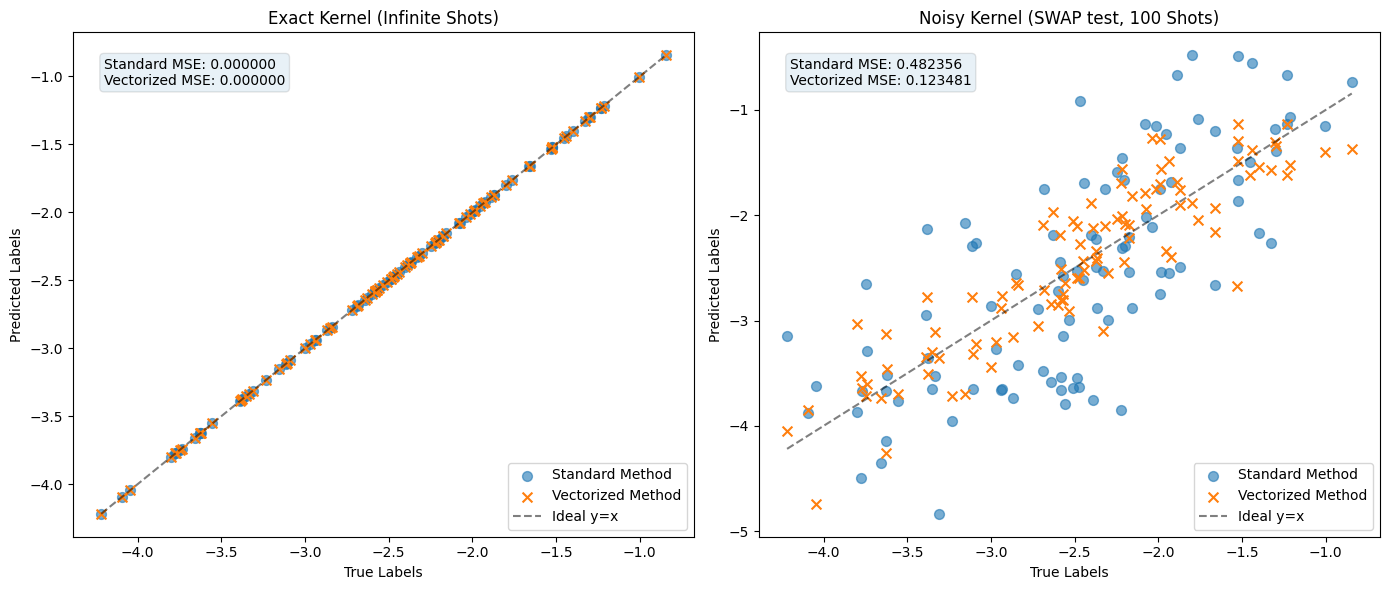

In [7]:
def generate_random_density_matrix(dim):
    """Generates a random valid density matrix (Hermitian, positive semi-definite, trace 1)."""
    A = np.random.randn(dim, dim) + 1j * np.random.randn(dim, dim)
    rho = A @ A.conj().T
    return rho / np.trace(rho)

def run_kernel_benchmark():
    # --- 1. SETUP MOCK QUANTUM DATA ---
    print("--- Setting up mock quantum data ---")
    N_train = 400
    N_test = 100
    dim = 4 # 2 qubits
    
    # Target function: y_i = Tr(O * rho_i)
    O_target = np.random.randn(dim, dim)
    O_target = O_target + O_target.T  # Symmetric observable

    # Generate Train and Test sets
    rho_train = [generate_random_density_matrix(dim) for _ in range(N_train)]
    y_train = np.array([np.real(np.trace(O_target @ rho)) for rho in rho_train])

    rho_test = [generate_random_density_matrix(dim) for _ in range(N_test)]
    y_test = np.array([np.real(np.trace(O_target @ rho)) for rho in rho_test])

    print(f"Generated {N_train} training samples and {N_test} testing samples.\n")

    # ==========================================================
    # === BENCHMARK 1: EXACT QKR (num_shots = None)          ===
    # ==========================================================
    print("=== BENCHMARK 1: EXACT CASE (num_shots=None) ===")
    qkr_exact = myQML.QuantumKernelRegression(regularization_lambda=0, num_shots=None)

    # Standard Method
    t0 = time.perf_counter()
    qkr_exact.fit(rho_train, y_train, kernel_type="trace")
    y_pred_std_exact = np.real(qkr_exact.predict(rho_test))
    time_std_exact = time.perf_counter() - t0

    # Vectorized Method
    t0 = time.perf_counter()
    qkr_exact.fit_vec(rho_train, y_train, kernel_type="trace")
    y_pred_vec_exact = np.real(qkr_exact.predict_vec(rho_test))
    time_vec_exact = time.perf_counter() - t0

    mse_std_exact = np.mean((y_test - y_pred_std_exact)**2)
    mse_vec_exact = np.mean((y_test - y_pred_vec_exact)**2)

    print(f"Standard time:   {time_std_exact:.4f} sec | MSE: {mse_std_exact:.8f}")
    print(f"Vectorized time: {time_vec_exact:.4f} sec | MSE: {mse_vec_exact:.8f}")
    print(f"Speedup:         {time_std_exact / time_vec_exact:.2f}x faster")
    print(f"Are predictions identical? {np.allclose(y_pred_std_exact, y_pred_vec_exact, atol=1e-10)}\n")


    # ==========================================================
    # === BENCHMARK 2: NOISY QKR (num_shots = 100)           ===
    # ==========================================================
    print("=== BENCHMARK 2: FINITE SHOT NOISE (num_shots=100) ===")
    qkr_noisy = myQML.QuantumKernelRegression(regularization_lambda=0, num_shots=10000)

    # Standard Method
    t0 = time.perf_counter()
    qkr_noisy.fit(rho_train, y_train, kernel_type="swap")
    y_pred_std_noisy = np.real(qkr_noisy.predict(rho_test))
    time_std_noisy = time.perf_counter() - t0

    # Vectorized Method
    t0 = time.perf_counter()
    qkr_noisy.fit_vec(rho_train, y_train, kernel_type="swap")
    y_pred_vec_noisy = np.real(qkr_noisy.predict_vec(rho_test))
    time_vec_noisy = time.perf_counter() - t0

    mse_std_noisy = np.mean((y_test - y_pred_std_noisy)**2)
    mse_vec_noisy = np.mean((y_test - y_pred_vec_noisy)**2)

    print(f"Standard time:   {time_std_noisy:.4f} sec | MSE: {mse_std_noisy:.8f}")
    print(f"Vectorized time: {time_vec_noisy:.4f} sec | MSE: {mse_vec_noisy:.8f}")
    print(f"Speedup:         {time_std_noisy / time_vec_noisy:.2f}x faster")
    print(f"Are predictions identical? {np.array_equal(y_pred_std_noisy, y_pred_vec_noisy)} (Expected: False)\n")

    # ==========================================================
    # === PLOTTING RESULTS                                   ===
    # ==========================================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Plot 1: Exact Case
    ax1.set_title("Exact Kernel (Infinite Shots)")
    ax1.scatter(y_test, y_pred_std_exact, alpha=0.6, s=50, label='Standard Method')
    ax1.scatter(y_test, y_pred_vec_exact, marker='x', s=50, label='Vectorized Method')
    
    min_val, max_val = min(y_test), max(y_test)
    ax1.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Ideal y=x')
    
    ax1.set_xlabel("True Labels")
    ax1.set_ylabel("Predicted Labels")
    ax1.legend()
    ax1.text(0.05, 0.95, f"Standard MSE: {mse_std_exact:.6f}\nVectorized MSE: {mse_vec_exact:.6f}", 
             transform=ax1.transAxes, verticalalignment='top', bbox=dict(boxstyle="round", alpha=0.1))

    # Plot 2: Noisy Case
    ax2.set_title("Noisy Kernel (SWAP test, 100 Shots)")
    ax2.scatter(y_test, y_pred_std_noisy, alpha=0.6, s=50, label='Standard Method')
    ax2.scatter(y_test, y_pred_vec_noisy, marker='x', s=50, label='Vectorized Method')
    
    ax2.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Ideal y=x')

    ax2.set_xlabel("True Labels")
    ax2.set_ylabel("Predicted Labels")
    ax2.legend()
    ax2.text(0.05, 0.95, f"Standard MSE: {mse_std_noisy:.6f}\nVectorized MSE: {mse_vec_noisy:.6f}", 
             transform=ax2.transAxes, verticalalignment='top', bbox=dict(boxstyle="round", alpha=0.1))

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_kernel_benchmark()